### Purpose
Construct the prediction target correctly in calendar time and define a strict time-ordered train/validation/test split within the selected session.


#### Project root setup

In [1]:
from pathlib import Path
import os
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing both 'config.yaml' and 'data' directory."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("cwd =", Path.cwd())

PROJECT_ROOT = /home/zakhar/PycharmProjects/PythonProject5
cwd = /home/zakhar/PycharmProjects/PythonProject5


#### Imports

In [2]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from src.io import save_table
from src.target_building import build_targets_by_session_inplace
from src.splits import add_time_split_with_purge_inplace, split_summary

#### Load `clean.parquet`

In [3]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

df = pd.read_parquet(cfg["data"]["clean_path"])

print("Shape:", df.shape)
print("Index:", type(df.index), df.index)
df.head()

Shape: (987938, 100)
Index: <class 'pandas.core.indexes.range.RangeIndex'> RangeIndex(start=0, stop=987938, step=1)


,timestamp,best_bid_price,best_bid_volume,best_ask_price,best_ask_volume,mid_price,spread,imbalance_l1,total_bid_volume,weighted_bid_volume,...,vwap_seller_taker_5s,source_file,file_date,event_dt,seconds_of_day,session_type,is_in_session,session_id,mid_reconstructed,mid_reconstruction_error
0,1748941200153000000,10.931,25,10.935,13,10.9330,0.004,-0.363636,1558.0,602.382143,...,NaN,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.153000000,32400,main,True,20250603_main,10.9330,0.0
1,1748941200390000000,10.931,25,10.935,13,10.9330,0.004,0.315789,509.0,114.003175,...,NaN,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.390000000,32400,main,True,20250603_main,10.9330,0.0
2,1748941200767000000,10.931,25,10.935,13,10.9330,0.004,0.315789,539.0,118.288889,...,NaN,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.767000000,32400,main,True,20250603_main,10.9330,0.0
3,1748941201003000002,10.930,12,10.935,13,10.9325,0.005,0.315789,569.0,121.288889,...,NaN,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:01.003000002,32401,main,True,20250603_main,10.9325,0.0
4,1748941201053000000,10.930,32,10.935,13,10.9325,0.005,-0.040000,661.0,135.965873,...,NaN,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:01.053000000,32401,main,True,20250603_main,10.9325,0.0


#### Subset sanity check

In [4]:
print("Unique file_date:", df["file_date"].astype(str).unique())
print("Unique session_type:", df["session_type"].unique())
print("Unique session_id:", df["session_id"].unique())
print("event_dt min:", df["event_dt"].min())
print("event_dt max:", df["event_dt"].max())

Unique file_date: ['20250603']
Unique session_type: ['main']
Unique session_id: ['20250603_main']
event_dt min: 2025-06-03 09:00:00.153000
event_dt max: 2025-06-03 18:49:59.777000


#### Add `row_id`

In [5]:
df["row_id"] = np.arange(len(df), dtype=np.int64)
df.head()

,timestamp,best_bid_price,best_bid_volume,best_ask_price,best_ask_volume,mid_price,spread,imbalance_l1,total_bid_volume,weighted_bid_volume,...,source_file,file_date,event_dt,seconds_of_day,session_type,is_in_session,session_id,mid_reconstructed,mid_reconstruction_error,row_id
0,1748941200153000000,10.931,25,10.935,13,10.9330,0.004,-0.363636,1558.0,602.382143,...,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.153000000,32400,main,True,20250603_main,10.9330,0.0,0
1,1748941200390000000,10.931,25,10.935,13,10.9330,0.004,0.315789,509.0,114.003175,...,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.390000000,32400,main,True,20250603_main,10.9330,0.0,1
2,1748941200767000000,10.931,25,10.935,13,10.9330,0.004,0.315789,539.0,118.288889,...,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:00.767000000,32400,main,True,20250603_main,10.9330,0.0,2
3,1748941201003000002,10.930,12,10.935,13,10.9325,0.005,0.315789,569.0,121.288889,...,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:01.003000002,32401,main,True,20250603_main,10.9325,0.0,3
4,1748941201053000000,10.930,32,10.935,13,10.9325,0.005,-0.040000,661.0,135.965873,...,CNYRUBF_20250603_features.parquet,20250603,2025-06-03 09:00:01.053000000,32401,main,True,20250603_main,10.9325,0.0,4


#### Build targets

In [6]:
%%time
build_targets_by_session_inplace(
    df,
    horizons_sec=cfg["time"]["horizons_sec"],
    event_col="event_dt",
    mid_col="mid_price",
    session_col="session_id",
)

CPU times: user 544 ms, sys: 58.5 ms, total: 602 ms
Wall time: 602 ms


#### Validity report

In [7]:
validity_rows = []

for h in cfg["time"]["horizons_sec"]:
    validity_rows.append({
        "horizon_sec": h,
        "valid_share": float(df[f"valid_target_{h}s"].mean()),
        "n_valid": int(df[f"valid_target_{h}s"].sum()),
        "n_total": int(len(df)),
    })

validity_report = pd.DataFrame(validity_rows)
validity_report

,horizon_sec,valid_share,n_valid,n_total
0,1,0.999998,987936,987938
1,5,0.999975,987913,987938
2,10,0.999963,987901,987938


#### Invalid-target sanity check

In [8]:
for h in cfg["time"]["horizons_sec"]:
    print("=" * 80)
    print(f"H = {h}s")

    tmp = (
        df.loc[~df[f"valid_target_{h}s"], ["event_dt"]]
          .tail(5)
    )
    display(tmp)

H = 1s


,event_dt
987936,2025-06-03 18:49:59.343000002
987937,2025-06-03 18:49:59.777000000


H = 5s


,event_dt
987933,2025-06-03 18:49:57.207000000
987934,2025-06-03 18:49:57.283000002
987935,2025-06-03 18:49:58.393000002
987936,2025-06-03 18:49:59.343000002
987937,2025-06-03 18:49:59.777000000


H = 10s


,event_dt
987933,2025-06-03 18:49:57.207000000
987934,2025-06-03 18:49:57.283000002
987935,2025-06-03 18:49:58.393000002
987936,2025-06-03 18:49:59.343000002
987937,2025-06-03 18:49:59.777000000


#### Time-based split with purge / embargo inside the session

In [9]:
purge_sec = cfg["experiment"].get("purge_sec", max(cfg["time"]["horizons_sec"]))

add_time_split_with_purge_inplace(
    df,
    train_ratio=cfg["experiment"]["split_ratios"]["train"],
    val_ratio=cfg["experiment"]["split_ratios"]["val"],
    test_ratio=cfg["experiment"]["split_ratios"]["test"],
    purge_sec=purge_sec,
    time_col="event_dt",
)

df["split"].value_counts()

split
train     591998
test      197352
val       196165
purged      2423
Name: count, dtype: int64

#### Split summary

In [10]:
active_df = df.loc[df["split"].isin(["train", "val", "test"])].copy()

split_time_summary = split_summary(active_df, time_col="event_dt")
split_time_summary

,split,min,max,count
1,train,2025-06-03 09:00:00.153,2025-06-03 14:09:51.860000009,591998
2,val,2025-06-03 14:10:12.007,2025-06-03 16:26:37.390000003,196165
0,test,2025-06-03 16:26:58.437,2025-06-03 18:49:59.777000000,197352


In [11]:
pd.Series({
    "train_rows": int((df["split"] == "train").sum()),
    "val_rows": int((df["split"] == "val").sum()),
    "test_rows": int((df["split"] == "test").sum()),
    "purged_rows": int((df["split"] == "purged").sum()),
})

train_rows     591998
val_rows       196165
test_rows      197352
purged_rows      2423
dtype: int64

#### Target summary

In [12]:
for h in cfg["time"]["horizons_sec"]:
    print("=" * 80)
    print(f"Target summary for H = {h}s")
    display(
        df.loc[df[f"valid_target_{h}s"], f"y_logret_{h}s"]
          .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    )

Target summary for H = 1s


count    987936.000000
mean          0.000003
std           0.000071
min          -0.000550
1%           -0.000229
5%           -0.000092
50%           0.000000
95%           0.000092
99%           0.000229
max           0.000777
Name: y_logret_1s, dtype: float64

Target summary for H = 5s


count    987913.000000
mean          0.000007
std           0.000119
min          -0.000777
1%           -0.000366
5%           -0.000183
50%           0.000000
95%           0.000183
99%           0.000411
max           0.001006
Name: y_logret_5s, dtype: float64

Target summary for H = 10s


count    987901.000000
mean          0.000006
std           0.000162
min          -0.001053
1%           -0.000502
5%           -0.000229
50%           0.000000
95%           0.000274
99%           0.000504
max           0.001417
Name: y_logret_10s, dtype: float64

#### Target histograms

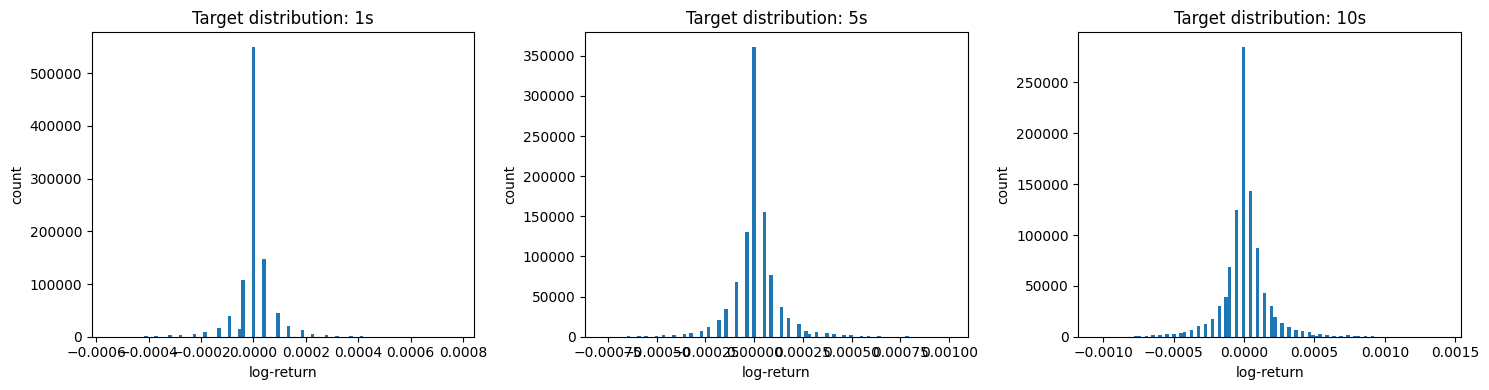

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h in zip(axes, cfg["time"]["horizons_sec"]):
    s = df.loc[df[f"valid_target_{h}s"], f"y_logret_{h}s"].dropna()
    ax.hist(s, bins=100)
    ax.set_title(f"Target distribution: {h}s")
    ax.set_xlabel("log-return")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

#### Validity by split

In [14]:
rows = []
for h in cfg["time"]["horizons_sec"]:
    tmp = (
        df.groupby("split")[f"valid_target_{h}s"]
          .mean()
          .rename("valid_share")
          .reset_index()
    )
    tmp["horizon_sec"] = h
    rows.append(tmp)

validity_by_split = pd.concat(rows, ignore_index=True)
validity_by_split

,split,valid_share,horizon_sec
0,purged,1.000000,1
1,test,0.999990,1
2,train,1.000000,1
3,val,1.000000,1
4,purged,1.000000,5
5,test,0.999873,5
6,train,1.000000,5
7,val,1.000000,5
8,purged,1.000000,10
9,test,0.999813,10


#### Near-zero target report

In [15]:
zero_like_rows = []

for h in cfg["time"]["horizons_sec"]:
    y = df.loc[df[f"valid_target_{h}s"], f"y_logret_{h}s"].dropna()
    zero_like_rows.append({
        "horizon_sec": h,
        "mean": float(y.mean()),
        "std": float(y.std()),
        "share_abs_lt_1e_8": float((y.abs() < 1e-8).mean()),
        "share_abs_lt_1e-6": float((y.abs() < 1e-6).mean()),
    })

zero_like_report = pd.DataFrame(zero_like_rows)
zero_like_report

,horizon_sec,mean,std,share_abs_lt_1e_8,share_abs_lt_1e-6
0,1,0.000003,0.000071,0.556971,0.556971
1,5,0.000007,0.000119,0.365526,0.365526
2,10,0.000006,0.000162,0.288513,0.288513


#### Build `targets_only`

In [16]:
target_cols_to_save = [
    "row_id",
    "timestamp",
    "event_dt",
    "file_date",
    "session_type",
    "session_id",
    "split",
]

for h in cfg["time"]["horizons_sec"]:
    target_cols_to_save += [
        f"future_dt_{h}s",
        f"future_mid_{h}s",
        f"valid_target_{h}s",
        f"delta_mid_{h}s",
        f"y_logret_{h}s",
    ]

targets_df = df[target_cols_to_save].copy()

print(targets_df.shape)
targets_df.head()

(987938, 22)


,row_id,timestamp,event_dt,file_date,session_type,session_id,split,future_dt_1s,future_mid_1s,valid_target_1s,...,future_dt_5s,future_mid_5s,valid_target_5s,delta_mid_5s,y_logret_5s,future_dt_10s,future_mid_10s,valid_target_10s,delta_mid_10s,y_logret_10s
0,0,1748941200153000000,2025-06-03 09:00:00.153000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.250,10.9415,True,0.0085,0.000777
1,1,1748941200390000000,2025-06-03 09:00:00.390000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.563,10.9415,True,0.0085,0.000777
2,2,1748941200767000000,2025-06-03 09:00:00.767000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.787000002,10.9320,True,...,2025-06-03 09:00:05.990000002,10.934,True,0.0010,0.000091,2025-06-03 09:00:11.057,10.9415,True,0.0085,0.000777
3,3,1748941201003000002,2025-06-03 09:00:01.003000002,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.030000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823
4,4,1748941201053000000,2025-06-03 09:00:01.053000000,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.057000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823


#### Save targets and summary tables

In [17]:
save_table(targets_df, cfg["data"]["targets_path"])
print("Saved:", cfg["data"]["targets_path"])

tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

validity_report.to_csv(tables_dir / "target_validity_report.csv", index=False)
validity_by_split.to_csv(tables_dir / "target_validity_by_split.csv", index=False)
zero_like_report.to_csv(tables_dir / "target_zero_like_report.csv", index=False)
split_time_summary.to_csv(tables_dir / "split_time_summary.csv", index=False)

print("Saved tables to", tables_dir.resolve())

Saved: outputs/datasets/targets_only.parquet
Saved tables to /home/zakhar/PycharmProjects/PythonProject5/outputs/tables


## Short notebook conclusion
This notebook defines the prediction target as a fixed-horizon future mid-price log-return in calendar time and creates a strict time-ordered split with a 10-second purge/embargo around split boundaries, reducing leakage risk for fixed-horizon targets. After purge, the active sample contains 591,998 train rows, 196,165 validation rows, and 197,352 test rows, while 2,423 rows are excluded from modeling around split boundaries.

## Key target-building findings

- The experiment is restricted to a single liquid market regime: the main trading session of 2025-06-03.
- Future targets are defined as fixed-horizon mid-price log-returns at 1s, 5s, and 10s.
- Since the experiment subset contains only one coherent session, target construction is straightforward and does not cross any inter-session gap.
- Train / validation / test are defined as a strict time-ordered split within the session, with a purge/embargo window around split boundaries equal to the maximum forecast horizon.
- Invalid targets arise only near the tail of the session, where no future observation exists at the required horizon.